
# Homework 5 — Logistic Regression for Credit Risk

**Objective:** Build a logistic regression model to predict `loan_status` from **5** features in `credit_risk_dataset.csv`.

- Load and explore the dataset  
- Pick **five** predictors (`X`) and define the target (`Y = loan_status`)  
- Split into train/test, fit a logistic model, and evaluate performance  
- Interpret signs/magnitudes of coefficients and comment on model quality  

> **Tip:** Keep your code readable and modular. Add short comments to explain each decision.



## Dataset

- File: `credit_risk_dataset.csv`  
- Target: `loan_status` (e.g., 1 = default, 0 = fully paid).  


## 1. Imports

In [11]:

# TODO: Import libraries
# Rules: use matplotlib (no seaborn), one chart per plot, don't set colors explicitly.
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
)



## 2. Load Data

In [2]:
# TODO: Load the dataset (try local first, then /mnt/data fallback)
loans = pd.read_csv('credit_risk_dataset.csv')

print(f"Loaded {len(loans):,} loans with {loans.shape[1]} columns")

Loaded 32,581 loans with 12 columns


## 3. Inspect & Clean

In [5]:
loans.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
# TODO: Basic inspection
status_counts = loans['loan_status'].value_counts()
print(status_counts)
print(f"\nMost loans ({status_counts.iloc[0] / len(loans):.0%}) are still 'Current' — i.e. they haven't finished yet.")

loan_status
0    25473
1     7108
Name: count, dtype: int64

Most loans (78%) are still 'Current' — i.e. they haven't finished yet.


## 4. Choose 4 Features (X) and Target (Y)

In [14]:

# TODO: Pick exactly five columns that you believe predict loan_status.
chosen_features = ["loan_percent_income", "loan_intent", "cb_person_default_on_file", "person_home_ownership", "loan_int_rate"]

data = loans[chosen_features + ['loan_status']].dropna()

for col in ['loan_intent', 'person_home_ownership', 'cb_person_default_on_file']:
    data[col] = LabelEncoder().fit_transform(data[col])

target_col = "loan_status"

X = data[chosen_features]
y = data['loan_status']

print(f"Final dataset: {X.shape[0]:,} rows, {X.shape[1]} features")

Final dataset: 29,465 rows, 5 features


## 5. Preprocess & Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Two kinds of predictions: hard labels and probabilities
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


Train: (20625, 5)  Test: (8840, 5)


## 6. Fit Logistic Regression

In [17]:
# Headline numbers
print(f"Accuracy : {model.score(X_test, y_test):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")

print("\nConfusion matrix (rows = actual, cols = predicted):")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

# Save the metrics so we can compare against the better models in Section 7.6.
# We compute precision/recall for the DEFAULT class (label 1) only.
from sklearn.metrics import precision_score, recall_score, f1_score
init_metrics = {
    'Accuracy'             : model.score(X_test, y_test),
    'ROC-AUC'              : roc_auc_score(y_test, y_proba),
    'Recall (defaults)'    : recall_score(y_test, y_pred, zero_division=0),
    'Precision (defaults)' : precision_score(y_test, y_pred, zero_division=0),
    'F1 (defaults)'        : f1_score(y_test, y_pred, zero_division=0),
}

# Save the ROC curve points too — Section 7.6 will plot all three overlapping.
init_fpr, init_tpr, _ = roc_curve(y_test, y_proba)
init_auc = roc_auc_score(y_test, y_proba)

Accuracy : 0.838
ROC-AUC  : 0.829

Confusion matrix (rows = actual, cols = predicted):
[[6592  309]
 [1120  819]]

Classification report:
              precision    recall  f1-score   support

           0      0.855     0.955     0.902      6901
           1      0.726     0.422     0.534      1939

    accuracy                          0.838      8840
   macro avg      0.790     0.689     0.718      8840
weighted avg      0.827     0.838     0.821      8840



## 7. Evaluate

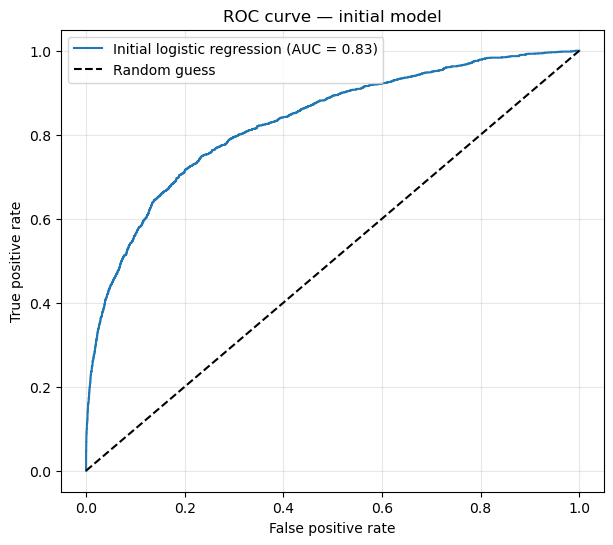

In [19]:

# ROC curve for the initial model
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Initial logistic regression (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve — initial model')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Coefficients / Feature Effects

In [ ]:
#Random forest with the same features
forest = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
forest.fit(X_train, y_train)

y_proba_rf = forest.predict_proba(X_test)[:, 1]
print(f"Logistic regression ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(f"Random forest       ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")

# Which features did the forest find most useful?
importances = pd.Series(forest.feature_importances_, index=X.columns)
print("\nTop 5 most important features:")
print(importances.sort_values(ascending=False).head(5).round(3))


Logistic regression ROC-AUC: 0.829
Random forest       ROC-AUC: 0.865

Top 5 most important features:
loan_int_rate                0.395
loan_percent_income          0.386
person_home_ownership        0.104
loan_intent                  0.084
cb_person_default_on_file    0.032
dtype: float64



## 9. Interpretation (Write-up)

- Which features increased default probability (positive coefficients)? Which decreased it?  
- How strong is the model? Comment on **accuracy** and **ROC-AUC**.  
- Discuss at least one **limitation** (e.g., class imbalance, omitted variables, nonlinearities, calibration).  
- Suggest one improvement (e.g., add interaction terms, regularization, or different features).


Positive coefficients within the model are "loan_int_rate", "loan_percent_income", "cb_person_default_on_file" columns. The negative coefficients are the "person_home_ownership" and "loan_intent" column. The model is relatively accurate, especially considering the ROC-AUC is just about as accurate as the headlining accuracy number (both >80%), however, in my opinion just above 80% accuracy is not high enough to trust when actually considering giving out a loan. One limitation could be the fact that we do not know how late each loan is on default. For example, in our class workthough, we split up the late payments of loans into chunks of how many days late each defaulted loan was. A workaround for this would be to add in those columns expressing how many days late a loan is. Another separate improvement that could be made could be knowing if the current person taking out a loan has other payment obligations (and potentially the value of those other liabilities).